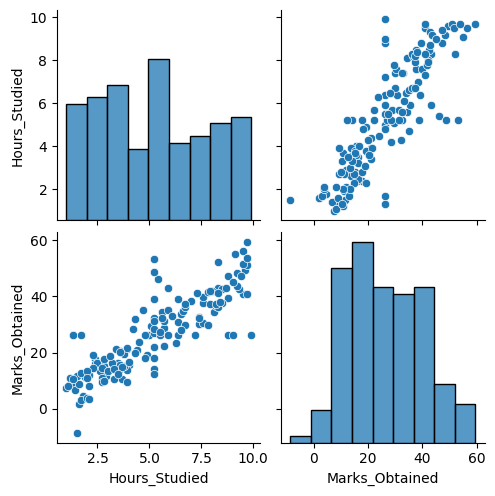

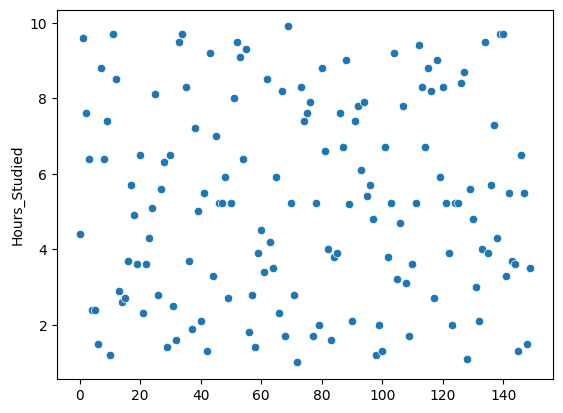

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Hours_Studied   150 non-null    float64
 1   Marks_Obtained  150 non-null    float64
dtypes: float64(2)
memory usage: 2.5 KB
X train of Data :(112, 1)
X test of Data  :(38, 1)
Y train of Data :(112,)
Y test of Data  :(38,)


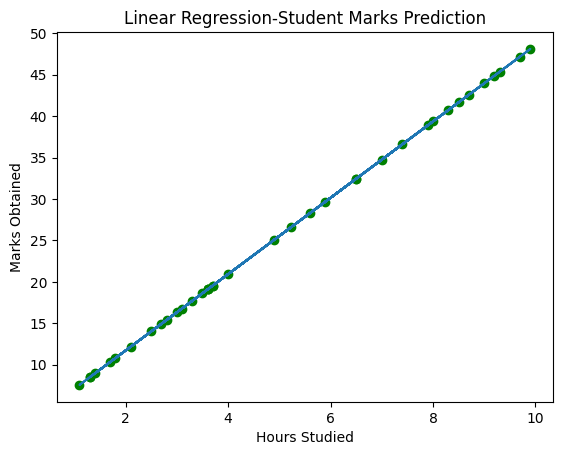

MSE:41.77583085752045
MAE:4.497966343820097
RSME:6.4634225343482266


In [39]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# import path
df_student = pd.read_csv(r"C:\Users\navne\Downloads\student_data_with_null.csv")
df_student


# find Here Null Values
df_student.isnull().sum()


# fill the null values of the mean
df_student["Hours_Studied"] = df_student["Hours_Studied"].fillna(df_student["Hours_Studied"].mean())
df_student["Marks_Obtained"] = df_student["Marks_Obtained"].fillna(df_student["Marks_Obtained"].mean())
sns.pairplot(df_student)
plt.show()

# Scatter plot 
sns.scatterplot(df_student["Hours_Studied"])
plt.show()


# Describe of the Data
df_student.describe()

# information Of the Data
df_student.info()

# correlation Of the Data
df_student.corr()



# sepration Of Data
x_data = df_student[["Hours_Studied"]]
y_data = df_student["Marks_Obtained"]

# Data Standradzation
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x_data,y_data,test_size = 0.25,random_state = 42)


print(f"X train of Data :{x_train.shape}")
print(f"X test of Data  :{x_test.shape}")
print(f"Y train of Data :{y_train.shape}")
print(f"Y test of Data  :{y_test.shape}")



# Standradzation of the Data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# fitting of the Data
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


# Linear regreassion of the Data
from sklearn.linear_model import LinearRegression
lr = LinearRegression()


# fitting Of the Data
lr.fit(x_train_scaled,y_train)

# coffiecent  and intercept of the value
lr.coef_,lr.intercept_


# here predict value
y_train_pred = lr.predict(x_train_scaled)

# here test value of predication
y_test_pred = lr.predict(x_test_scaled)



# Here Scatter plot of train
plt.scatter(x_test,y_test_pred,color = "green")
plt.plot(x_test,lr.predict(x_test_scaled))
plt.xlabel("Hours Studied")
plt.ylabel("Marks Obtained")
plt.title("Linear Regression-Student Marks Prediction")
plt.show()



# performance of metrics

from sklearn.metrics import mean_absolute_error,mean_squared_error
mae = mean_absolute_error(y_test,y_test_pred)
mse = mean_squared_error(y_test,y_test_pred)
rsme = np.sqrt(mse)
print(f"MSE:{mse}")
print(f"MAE:{mae}")
print(f"RSME:{rsme}")